# Assignment2
Yunpei GU

In [65]:
import numpy as np

## Q 1.1: Implementation of the Sigmoid Function
σ(z) = 1 / (1+e^(−z))

In [66]:
def sigmoid( x ):
  """
  This function implements the logistic regression algorithm.
  Args:
    x: A numpy array of shape (d,) or (N, d) representing
      the input data.
  Returns:
    y: A numpy array of shape (l,) or (N, l) representing
      the output data.
  """
  
  # implement σ(z) = 1 / (1+e^(−z))
  y = 1 / (1 + np.exp(-x))

  return y


## Q 1.2: One Layer Inference: Logistic Regression

h = σ(Wx + b)

In [68]:
def inference_layer(X, W, b):
  """
  Implements the forward propagation for the logistic regression model.
  Args:
    X: The input data, of shape (number of features, number of examples).
    w: Weights, a numpy array of shape l x d.
    b: Bias, a scalar.
  Returns:
    y: The output of shape l or l x N
  """
  
  # print(W.shape)
  # print(X.shape)

  # implement h = σ(Wx + b)
  y = sigmoid(np.dot(W, X) + b)


  return y

In [69]:
# test inferenc_layer
X = np.array([[1.0, 2.0], [3.0, 4.0]])  # (d=2, N=2)
W = np.array([[0.5, -0.5]])            # (l=1, d=2)
b = np.array([[0.0]])                  # (l=1, 1)

output = inference_layer(X, W, b)
print(output)

# Test with higher-dimensional data
X = np.array([[1.0, 2.0, 3.0],  # d=4, N=3 (4 features, 3 samples)
                [4.0, 5.0, 6.0],
                [7.0, 8.0, 9.0],
                [10.0, 11.0, 12.0]])  # Shape (4, 3)

W = np.array([[0.2, -0.1, 0.5, -0.3],   # l=2, d=4 (2 output units, 4 features)
                [0.1, 0.4, -0.2, 0.6]])  # Shape (2, 4)

b = np.array([[0.1],                   # l=2 (bias for 2 output units)
                [-0.2]])                # Shape (2, 1)

output = inference_layer(X, W, b)
print(output)

[[0.26894142 0.26894142]]
[[0.59868766 0.66818777 0.73105858]
 [0.99776215 0.99908895 0.99962939]]


## Q 1.3: Two Layer Inference: Neural Network
yˆ = σ(w2σ(W1x + b1) + b2)

In [94]:
def inference_2layers(X, W1, W2, b1, b2):
  """
  Implements the forward propagation of a two layer neural network
  model.
  - Let d be the number of features (dimensionality) of the input.
  - Let N be the number of data samples in your batch
  - Let H be the number of hidden units
  Args:
  X: The input data, with shape either d or d x N
  W1: Weights for the first weight matrix: shape = H x d
  w2: Weights for the second matrix: shape = 1 x H
  b1: Bias value for first layer
  b2: Bias value for second layer
  Returns:
  y: Singular output data (1, 0), with shape either 1 or N.
  """
  
  # First layer forward propagation: h = σ(W1X + b1)
  h = inference_layer(X, W1, b1)

  # Second layer forward propagation: y = σ(W2h + b2)
  y = inference_layer(h, W2, b2)

  return y


In [72]:
# test inference_2layers
X = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
W1 = np.array([[0.2, -0.1], [0.5, 0.3]]) 
b1 = np.array([[0.1], [-0.1]]) 
W2 = np.array([[0.3, -0.5]])
b2 = np.array([[0.2]]) 

output = inference_2layers(X, W1, W2, b1, b2)
print(output)

[[0.48163253 0.4729231  0.46930779]]


# Q 1.4: Implementation of BCE Loss

$$\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]$$


In [73]:
def bce_forward(yhat, y):
  """
  This function calculates the gradient of the logistic regression cost
  function with respect to the weights and biases.
  Args:
    yhat: A numpy array of shape (N,) representing the predicted outputs
    y: A numpy array of shape (N,) representing the target labels.
  Returns:
    loss_value
  """
  # use cliping to avoid log(0) (clipping predicted probabilities to a safe range)
  # if the predicted y is very close to 0 or 1, the log value would be infinite
  yhat = np.clip(yhat, 1e-10, 1 - 1e-10)

  # compute the BCE loss for each sample
  individual_losses = y * np.log(yhat) + (1-y) * np.log(1 - yhat)

  # compute the averate loss across all samples
  loss_value = - np.mean(individual_losses)

  return loss_value

In [74]:
# test bce_forward
yhat = np.array([0.9, 0.8, 0.2, 0.1]) 
y = np.array([1, 1, 0, 0]) 

loss = bce_forward(yhat, y)

print("Predicted probabilities (yhat):", yhat)
print("True labels (y):", y)
print("Binary Cross-Entropy Loss:", loss)

Predicted probabilities (yhat): [0.9 0.8 0.2 0.1]
True labels (y): [1 1 0 0]
Binary Cross-Entropy Loss: 0.16425203348601802


## Q3: Implement Gradients

In [77]:
def gradients(X, y, W1, W2, b1, b2):
  '''
  Calculate the gradients of the cost functions with respect to W1, W2, b1, and
  Args:
    W1: Weight np.array of shape (h, d), first layer
    b1: Bias np.array of shape (h,), first layer
    W2: Weight np.array of shape (1, h), second layer
    b2: Bias value, second layer 

X: Input data of shape (d, N) representing the input data.
    y: Target / output labels of shape (N,)
  Returns:
    dL/dW1: Derivative of cost fxn w/r/t W1
    dL/db1: Derivative of cost fxn w/r/t b1
    dL/dW2: Derivative of cost fxn w/r/t W2
    dL/db2: Derivative of cost fxn w/r/t b2
    L: Loss value
  '''
  
  # Forward Pass
  h = inference_layer(X, W1, b1) # Hidden layer output (h, N)
  yhat = inference_layer(h, W2, b2) # Final prediction (1, N)

  # compute loss
  L = bce_forward(yhat, y)

  N = X.shape[1] # Number of samples in batch

  # Backward Pass (Gradient Calculation)

  # Compute dL/dyhat * dyhat/dz2 (Gradient of Loss w.r.t Output)
  dL_dz2 = (yhat - y) / N # Shape: (1, N)

  # Gradient of loss w.r.t W2
  dL_dW2 = dL_dz2 @ h.T # (1, N) @ (N, h) -> (1, h)

  # Gradient of loss w.r.t b2 (Sum across batch)
  dL_db2 = dL_dz2.sum(axis=1, keepdims=True) # Shape: (1, 1)

  # Compute gradient w.r.t hidden layer (Applying chain rule)
  dL_dz1 = W2.T @ dL_dz2 * h * (1 - h) # (h, 1) * (h, N) * (h, N) -> (h, N)

  # Gradient of loss w.r.t W1
  dL_dW1 = dL_dz1 @ X.T # (h, N) @ (N, d) -> (h, d)

  # Gradient of loss w.r.t b1 (Sum across batch)
  dL_db1 = dL_dz1.sum(axis=1, keepdims=True) # Shape: (h, 1)

  return dL_dW1, dL_dW2, dL_db1, dL_db2, L


In [78]:
X = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
W1 = np.array([[0.2, -0.1], [0.5, 0.3]]) 
b1 = np.array([[0.1], [-0.1]]) 
W2 = np.array([[0.3, -0.5]])
b2 = np.array([[0.2]]) 
y = inference_2layers(X, W1, W2, b1, b2)

r = gradients(X, y, W1, W2, b1, b2)
for i in r:
    print(i)

[[0. 0.]
 [0. 0.]]
[[0. 0.]]
[[0.]
 [0.]]
[[0.]]
0.691804806498908


## Q4: Optimization
 use the functions that you’ve implemented in the prior questions in order to optimize for the parameters W and b.

In [79]:
def update_params (batchx, batchy, W1, b1, W2, b2, lr = 0.01):
    '''
    Updates your parameters
    batchx: Mini-batch of features batchy: Corresponding mini-batch of labels
    W1: Starting value of W1
    b1: Starting value of b1
    W2: Starting value of W2
    b2: Starting value of b2
    Ir: Learning parameter, default to 0.01
    Returns
    W1: New value of W1
    b1: New value of b1
    W2: New value of W2
    b2: New value of b2
    '''
    dL_dW1, dL_dW2, dL_db1, dL_db2, L = gradients(batchx, batchy, W1, W2, b1, b2)

    # Gradient descent update step
    W1 -= lr * dL_dW1  # Update W1
    b1 -= lr * dL_db1  # Update b1
    W2 -= lr * dL_dW2  # Update W2
    b2 -= lr * dL_db2  # Update b2

    return W1, b1, W2, b2

## Q5: Putting it All Together

In [84]:
# Import utility functions with NLTK
import pickle
import numpy as np
import nltk
from utils import extract_features

nltk.download('twitter_samples')
nltk.download('stopwords')
              
def train_nn(filename, hidden_layer_size, iters=1e6, lr = 0.01):
    '''
    Reads in data (twitter_data.pkl), initiates parameters, extracts features
    and returns the parameters
    Returns:
        W1, b1, W2, b2, test_x, text_y, freqs (??????最后这三个需要在这里return吗)
    '''
    # Load the data
    with open(filename, 'rb') as f:
        data = pickle.load(f)

    train_x = data['train_x']
    train_y = data['train_y']
    test_x = data['test_x']
    test_y = data['test_y']
    freqs = data['freqs']

    # Review the data
    print("Training Data: ", train_x[0])

    # Convert training data into feature vectors
    # print(X.shape) # (3,1,8000)
    # print(W1.shape) # (10, 3)
    X_train = np.array([extract_features(tweet, freqs) for tweet in train_x]).squeeze().T
    X_test = np.array([extract_features(tweet, freqs) for tweet in test_x]).squeeze().T

    # Convert labels to numpy arrays
    Y_train = np.array(train_y).reshape(1, -1)
    Y_test = np.array(test_y).reshape(1, -1)

    # Initialize parameters
    d = X_train.shape[0]  # Number of input features
    H = hidden_layer_size  # Number of hidden units
    W1 = np.random.randn(H, d) * 0.01
    b1 = np.zeros((H, 1))
    W2 = np.random.randn(1, H) * 0.01
    b2 = np.zeros((1, 1))

    # Training loop
    for i in range(int(iters)):
        # Forward propagation
        yhat = inference_2layers(X_train, W1, W2, b1, b2)

        # Compute loss
        loss = bce_forward(yhat, Y_train)

        # Compute gradients
        dW1, dW2, db1, db2, _ = gradients(X_train, Y_train, W1, W2, b1, b2)

        # Update parameters using gradient descent
        W1, b1, W2, b2 = update_params(X_train, Y_train, W1, b1, W2, b2, lr)

        # Print loss every 10000 iterations
        if i % 10000 == 0:
            print(f"Iteration {i}: Loss = {loss}")

    print("Training complete.")

    return W1, b1, W2, b2, test_x, test_y, freqs


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/guyunpei/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/guyunpei/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/guyunpei/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/guyunpei/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Training Data:  #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
Iteration 0: Training Loss = 0.7002, Test Loss = 0.7002
Iteration 50: Training Loss = 0.5237, Test Loss = 0.5235
Iteration 100: Training Loss = 0.4094, Test Loss = 0.4088


/var/folders/g7/t4hq6htx355_vhxmxcsqvt5c0000gn/T/ipykernel_79630/1001347429.py:13: RuntimeWarning: overflow encountered in exp
  y = 1 / (1 + np.exp(-x))


Iteration 150: Training Loss = 0.3251, Test Loss = 0.3245
Iteration 200: Training Loss = 0.2646, Test Loss = 0.2638
Iteration 250: Training Loss = 0.2221, Test Loss = 0.2212
Iteration 300: Training Loss = 0.1910, Test Loss = 0.1901
Iteration 350: Training Loss = 0.1674, Test Loss = 0.1666
Iteration 400: Training Loss = 0.1490, Test Loss = 0.1482
Iteration 450: Training Loss = 0.1344, Test Loss = 0.1336
Iteration 500: Training Loss = 0.1225, Test Loss = 0.1217
Iteration 550: Training Loss = 0.1126, Test Loss = 0.1118
Iteration 600: Training Loss = 0.1043, Test Loss = 0.1035
Iteration 650: Training Loss = 0.0973, Test Loss = 0.0965
Iteration 700: Training Loss = 0.0912, Test Loss = 0.0905
Iteration 750: Training Loss = 0.0848, Test Loss = 0.0840
Iteration 800: Training Loss = 0.0797, Test Loss = 0.0790
Iteration 850: Training Loss = 0.0754, Test Loss = 0.0746
Iteration 900: Training Loss = 0.0716, Test Loss = 0.0708
Iteration 950: Training Loss = 0.0682, Test Loss = 0.0674
Iteration 1000

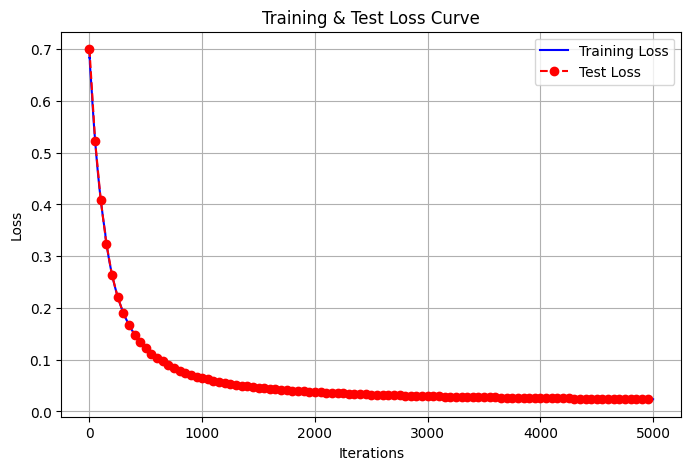

successfully save params


In [95]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import nltk
from utils import extract_features

nltk.download('twitter_samples')
nltk.download('stopwords')

def train_nn(filename, hidden_layer_size, iters=1e5, lr=0.01):
    '''
    Reads in data (twitter_data.pkl), initiates parameters, extracts features
    and returns the parameters
    Returns:
        W1, b1, W2, b2
    '''
    # load the data
    with open(filename, 'rb') as f:
        data = pickle.load(f)

    train_x = data['train_x']
    train_y = data['train_y']
    test_x = data['test_x']
    test_y = data['test_y']
    freqs = data['freqs']

    # Review the data 
    print("Training Data: ", train_x[0])
    
    # convert training data into feature vectors
    # print(X.shape) # (3,1,8000)
    # print(W1.shape) # (10, 3)
    X_train = np.array([extract_features(tweet, freqs) for tweet in train_x]).squeeze().T
    X_test = np.array([extract_features(tweet, freqs) for tweet in test_x]).squeeze().T

    # convert labels to numpy arrays
    Y_train = np.array(train_y).reshape(1, -1)
    Y_test = np.array(test_y).reshape(1, -1)

    # initialize parameters
    d = X_train.shape[0]  # number of input features
    H = hidden_layer_size  # number of hidden units
    W1 = np.random.randn(H, d) * 0.01
    b1 = np.zeros((H, 1))
    W2 = np.random.randn(1, H) * 0.01
    b2 = np.zeros((1, 1))

    # record the looses
    training_losses = []
    testing_losses = []
    iterations = []

    # training loop
    for i in range(int(iters)):
        # forward propagation
        yhat_train = inference_2layers(X_train, W1, W2, b1, b2)

        # compute losses
        loss_train = bce_forward(yhat_train, Y_train)
        training_losses.append(loss_train)

        # print loss every 50 iterations
        if i % 50 == 0:
            yhat_test = inference_2layers(X_test, W1, W2, b1, b2)
            loss_test = bce_forward(yhat_test, Y_test)
            testing_losses.append(loss_test)
            iterations.append(i)
            print(f"Iteration {i}: Training Loss = {loss_train:.4f}, Test Loss = {loss_test:.4f}")
        
        # update the parameters accoding to the gradient
        W1, b1, W2, b2 = update_params(X_train, Y_train, W1, b1, W2, b2, lr)

    print("Training complete.")
    print(len(training_losses))
    print(len(testing_losses))

    # draw the training and testing looses
    plt.figure(figsize=(8, 5))
    plt.plot(range(int(iters)), training_losses, label="Training Loss", color='blue')
    plt.plot(iterations, testing_losses, label="Test Loss", marker='o', linestyle='dashed', color='red')
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Training & Test Loss Curve")
    plt.legend()
    plt.grid()
    plt.show()

    return W1, b1, W2, b2

W1, b1, W2, b2 = train_nn("twitter_data.pkl", hidden_layer_size=10, iters=5000, lr=0.01)

# save params to pkl file
params = {
    'W1': W1,
    'W2': W2,
    'b1': b1,
    'b2': b2
}

with open('assignment2.pkl', 'wb') as f:
    pickle.dump(params, f)

print("successfully save params")




In [104]:
with open("twitter_data.pkl", 'rb') as f:
    data = pickle.load(f)

freqs = data['freqs']

test_tweets = [
    "I love this movie, it's fantastic!",
    "This is the worst film I have ever seen.",
    "Not bad, but could be better.",
    "Absolutely amazing! A must-watch.",
    "I regret watching this, waste of time."
]

for tweet in test_tweets:
    features = extract_features(tweet, freqs).T  
    y_hat = inference_2layers(features, W1, W2, b1, b2)
    print(f'Tweet: {tweet}')
    if y_hat > 0.5:
        print('Positive sentiment')
    else:
        print('Negative sentiment')
    

Tweet: I love this movie, it's fantastic!
Positive sentiment
Tweet: This is the worst film I have ever seen.
Negative sentiment
Tweet: Not bad, but could be better.
Negative sentiment
Tweet: Absolutely amazing! A must-watch.
Positive sentiment
Tweet: I regret watching this, waste of time.
Negative sentiment
